# libraries

In [1]:
#libraries and dirrectory 
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import patientFunctions as ptfn
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches


# directories

In [2]:
#updates to directory management
# machine_directory = 'C:/Users/mcremer' #the C and path to the project folder
machine_directory = 'C:/Users/maega' #when working from home machine
storage_directory = 'UFL Dropbox/Maegan Cremer/research-share/Maegan/Projects' #Local, HPG, or dropbox
project_directory = 'Cardiac-Amyloidosis-Multiple-Myeloma' #project folder
project_lv2_directory = '019_1_Mistic_ClinicalSplit_CodeOcean' #deeper part of project folder

path = os.path.join(machine_directory, storage_directory, 
                    project_directory, project_lv2_directory)

# parent_dir = path
outputDir = path
os.chdir(outputDir)

# data prep

In [236]:
dict_rocData = pd.read_excel("CodeOcean Outputs/ParamsOnly_clinSplit_Second_250820_v1/ParamsOnly_clinSplit_Second__250820_v1.xlsx", sheet_name=None)

In [237]:
dict_rocData.keys()

dict_keys(['svm_all_blind', 'svm_all_blind_roc', 'rnd_all_blind', 'rnd_all_blind_roc', 'rnd_all_blind_featureRank', 'xgb_all_blind', 'xgb_all_blind_roc', 'xgb_all_featureRank', '09_best model perf', '09_features', '09_blindprediction', 'svm_best_blind_roc', 'concat_best model perf', 'concat_features', 'concat_blindprediction', 'rnd_svm_rank', 'rnd_svm_blind', 'rnd_svm_blind_roc', 'xgb_svm_rank', 'xgb_svm_blind', 'xgb_svm_blind_roc', 'rnd_top_rank', 'rnd_top_blind', 'rnd_best_blind_roc'])

In [238]:
sheetNames_ROC = [sheet for sheet in dict_rocData.keys() if 'roc' in sheet]
sheetNames_ROC

['svm_all_blind_roc',
 'rnd_all_blind_roc',
 'xgb_all_blind_roc',
 'svm_best_blind_roc',
 'rnd_svm_blind_roc',
 'xgb_svm_blind_roc',
 'rnd_best_blind_roc']

In [239]:
dict_submodels = {}
for sheetName in sheetNames_ROC:
    submodel_name = re.split(re.escape('_'), sheetName)[:2]
    submodel_name=' '.join(submodel_name)
    dict_submodels[submodel_name]=dict_rocData[sheetName]

In [240]:
dict_submodels.keys()

dict_keys(['svm all', 'rnd all', 'xgb all', 'svm best', 'rnd svm', 'xgb svm', 'rnd best'])

In [241]:
dict_submodels_labeled = {}
for submodel in dict_submodels.keys():
    data = dict_submodels[submodel].T
    data[submodel] = [submodel for i in range(len(data))]
    data.columns = ['fpr', 'tpr', 'thresholds', 'model']
    data = data.T.iloc[:,1:].T
    dict_submodels_labeled[submodel] = data

In [242]:
i = 0
for submodel in dict_submodels_labeled.keys():
    if i == 0: 
        outputDataFrame = dict_submodels_labeled[submodel]
        i = i+1
    else:
        outputDataFrame = pd.concat([outputDataFrame, dict_submodels_labeled[submodel]], axis = 0)

outputDataFrame

,fpr,tpr,thresholds,model
0,0.0,0.0,inf,svm all
1,0.0,0.2,2.251302,svm all
2,0.2,0.2,1.051994,svm all
3,0.4,0.2,0.602064,svm all
4,0.4,0.4,0.558178,svm all
...,...,...,...,...
6,0.4,0.8,0.48,rnd best
7,0.4,1.0,0.32,rnd best
8,0.6,1.0,0.31,rnd best
9,0.8,1.0,0.25,rnd best


# import data roc tables

In [3]:
list_files = os.listdir("ROC_data")
list_files

['DescFits_025_ROC.csv',
 'DescFits_Second_ROC.csv',
 'DescOnly_025_ROC.csv',
 'DescOnly_Second_ROC.csv',
 'EchoAdj_025_ROC.csv',
 'EchoAdj_Second_ROC.csv',
 'ParamsOnly_025_ROC.csv',
 'ParamsOnly_Second_ROC.csv']

In [4]:
#find the ones with 025 for the long files and second for the short
#importing the data
dict_Long = {}
dict_short = {}

for fileName in list_files:
    address = os.path.join('ROC_data', fileName)
    if '025' in fileName:
        data = pd.read_csv(address)
        model_name = re.split(re.escape('_'), fileName)[0]
        dict_Long[model_name] = data
    if 'Second' in fileName: 
        data = pd.read_csv(address)
        model_name = re.split(re.escape('_'), fileName)[0]
        dict_short[model_name] = data


# ROC plots for the full feature list models

## after feature selection

In [ ]:
auc_firstRound_after = {'EchoAdj': {'svm best': '0.4', 'rnd svm': '0.64', 'rnd best': '0.8', 'xgb svm': '0.64'}, 
                  'DescOnly': {'svm best': 	'0.92', 'rnd best': "0.72", 'rnd svm' : '0.76', 'xgb svm': '0.56'},
                  'ParamsOnly': {'svm best': '0.68', 'rnd best': "0.68", 'rnd svm' : '0.76', 'xgb svm': '0.76'}, 
                  'DescFits': {'svm best': 	'0.96', 'rnd best': "0.84", 'rnd svm' : '0.84', 'xgb svm': '0.8'}}

auc_second_after = {'EchoAdj': {'svm best': '0.36', 'rnd svm': '0.74', 'rnd best': '0.76', 'xgb svm': '0.64'}, 
                  'DescOnly': {'svm best': 	'0.75', 'rnd best': "0.334", 'rnd svm' : '0.75', 'xgb svm': '0.57'},
                  'ParamsOnly': {'svm best': '0.76', 'rnd best': "0.72", 'rnd svm' : '0.76', 'xgb svm': '0.8'}, 
                  'DescFits': {'svm best': 	'1', 'rnd best': "0.62", 'rnd svm' : '0.62', 'xgb svm': '0.52'}}

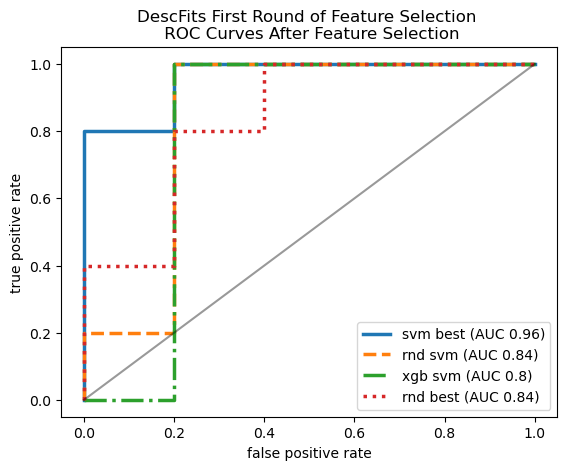

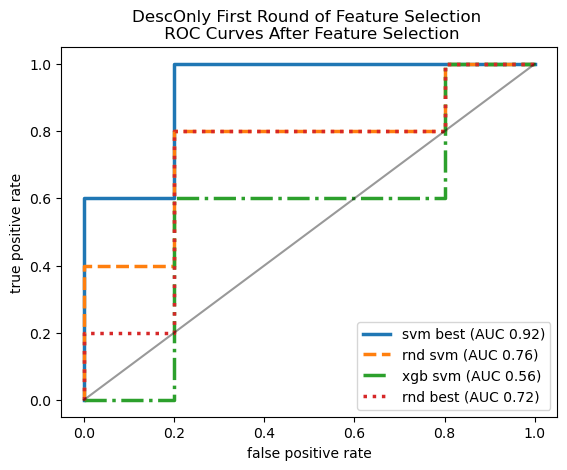

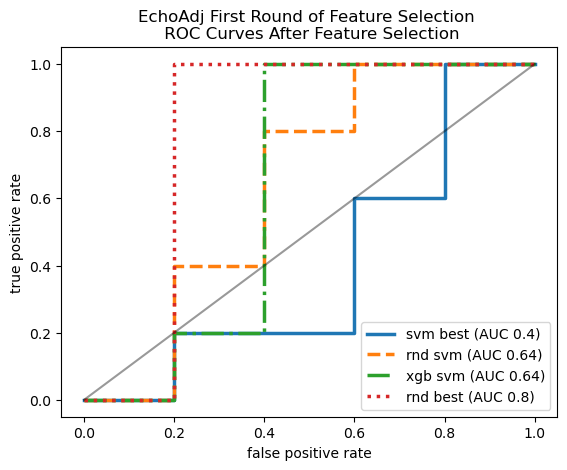

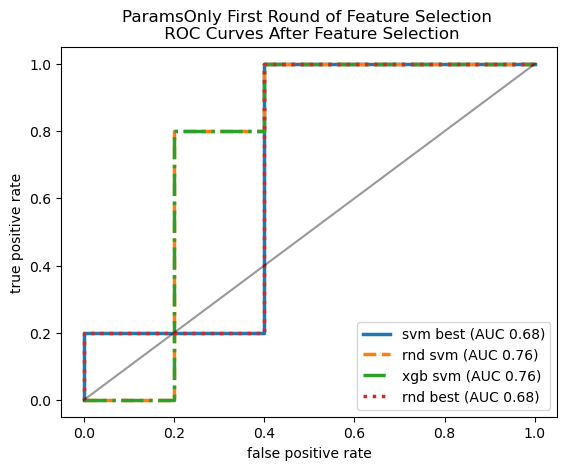

In [46]:
linestyles = ['-', '--', '-.', ':', '']
i = 0
for model in dict_Long.keys():
    data_main = dict_Long[model]
    #get the unique list of models run as part of that system
    listofUniqueModelsInSheet = data_main['model'].unique()

    #plot the ROC curve for the models after feature selection
    i = 0
    for submodel in listofUniqueModelsInSheet:
        if 'all' not in submodel:
            data = data_main[data_main['model']== submodel]
            plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth = 2.5,
                      label = submodel + " (AUC " + auc_firstRound_after[model][submodel] + ")")
            # plt.scatter(data['fpr'], data['tpr'],alpha = 0.25)
            i= i+1
    plt.plot([0,1], [0,1], 'k-', alpha =0.40, linewidth = 1.5)
    plt.title(model + " First Round of Feature Selection \n ROC Curves After Feature Selection")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.legend()
    plt.show()

## before feature selection

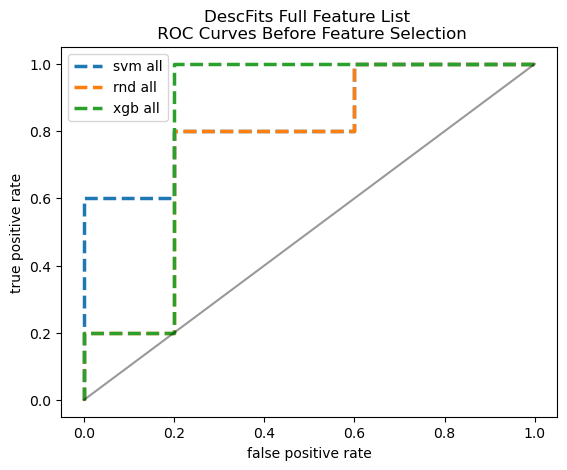

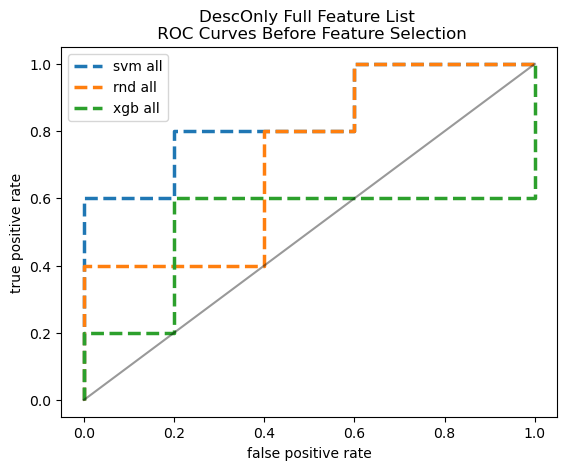

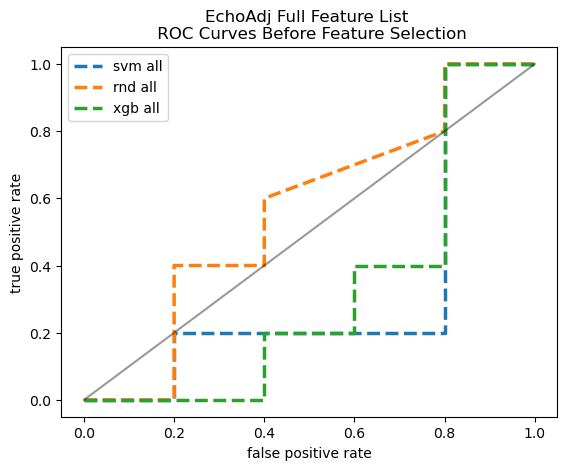

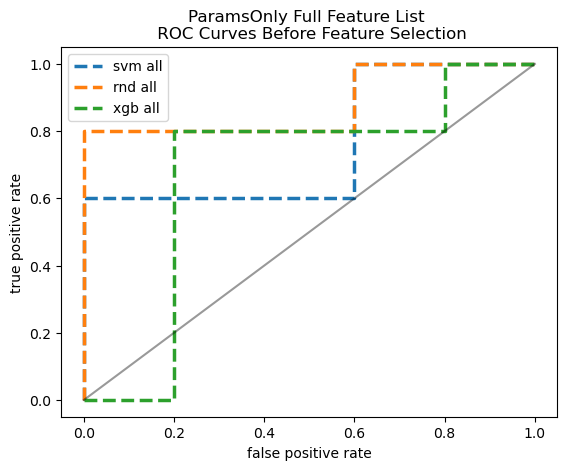

In [25]:
for model in dict_Long.keys():
    data_main = dict_Long[model]
    #get the unique list of models run as part of that system
    listofUniqueModelsInSheet = data_main['model'].unique()

    #plot the ROC curve for the models after feature selection
    for submodel in listofUniqueModelsInSheet:
        if 'all' in submodel:
            data = data_main[data_main['model']== submodel]
            plt.plot(data['fpr'], data['tpr'],'--', linewidth = 2.5, label = submodel)
            # plt.scatter(data['fpr'], data['tpr'],alpha = 0.25)
    plt.plot([0,1], [0,1], 'k-', alpha = 0.4, linewidth = 1.5)
    plt.title(model + " Full Feature List \n ROC Curves Before Feature Selection")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.legend()
    plt.show()

# ROC plots for the simplified models

## after feature selection

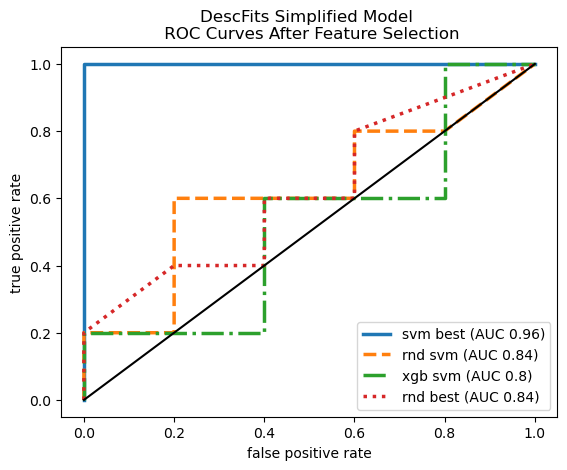

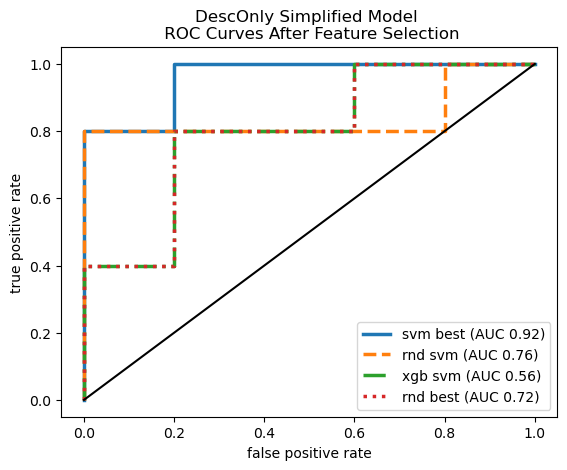

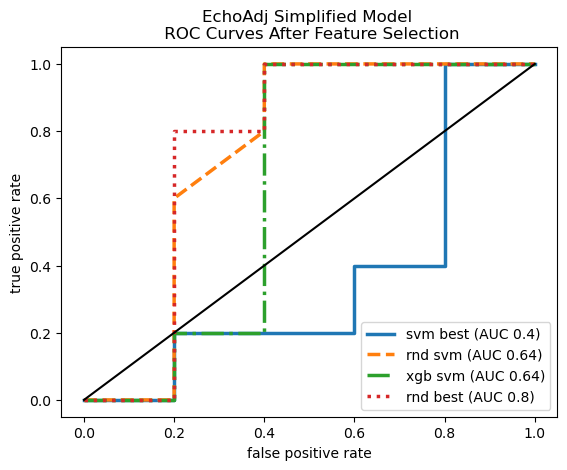

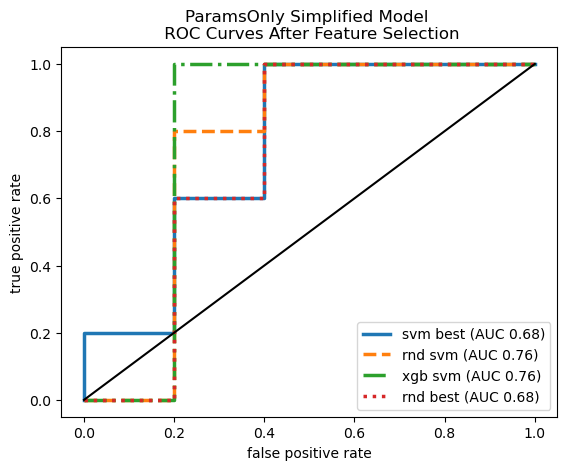

In [27]:
linestyles = ['-', '--', '-.', ':', '']
for model in dict_short.keys():
    data_main = dict_short[model]
    #get the unique list of models run as part of that system
    listofUniqueModelsInSheet = data_main['model'].unique()

    #plot the ROC curve for the models after feature selection
    i=0
    for submodel in listofUniqueModelsInSheet:
        if 'all' not in submodel:
            data = data_main[data_main['model']== submodel]
            plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth = 2.5,
                      label = submodel + " (AUC " + auc_second_after[model][submodel] + ")")
            i = i+1
    plt.plot([0,1], [0,1], 'k-', linewidth = 1.5)
    plt.title(model + " Simplified Model \n ROC Curves After Feature Selection")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.legend()
    plt.show()

## before feature selection

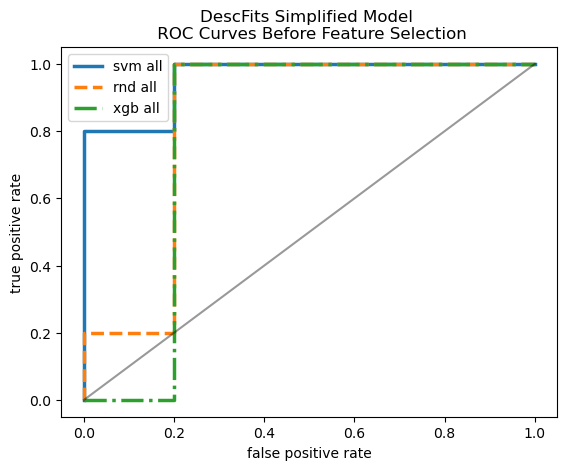

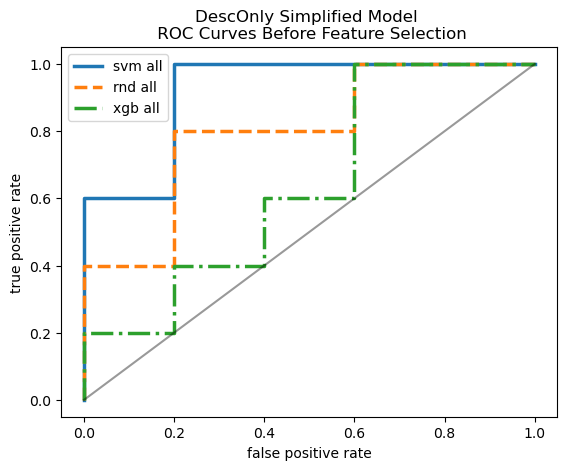

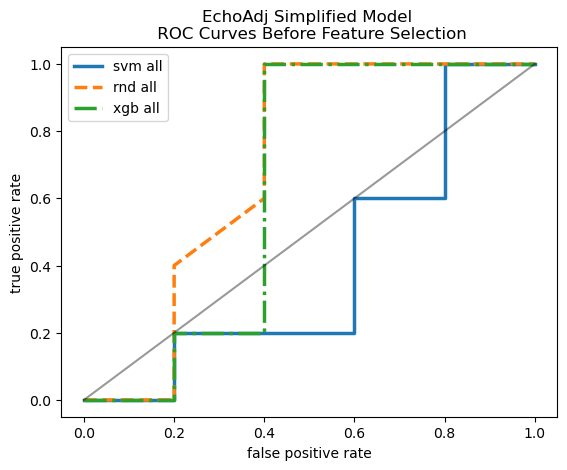

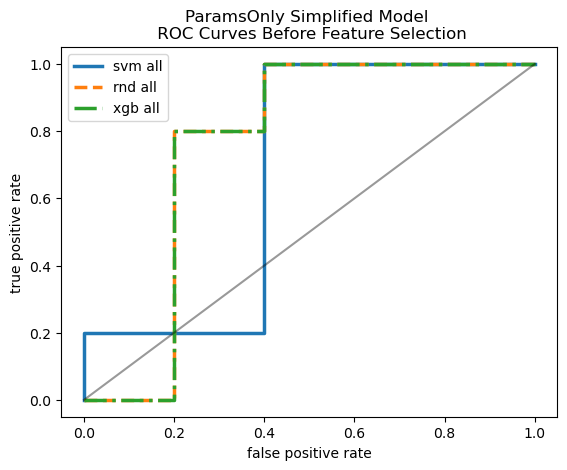

In [29]:
for model in dict_short.keys():
    data_main = dict_short[model]
    #get the unique list of models run as part of that system
    listofUniqueModelsInSheet = data_main['model'].unique()

    #plot the ROC curve for the models after feature selection
    i =0
    for submodel in listofUniqueModelsInSheet:
        if 'all' in submodel:
            data = data_main[data_main['model']== submodel]
            plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth = 2.5, label = submodel)
            i = i+1
    plt.plot([0,1], [0,1], 'k-', linewidth = 1.5, alpha = 0.4)
    plt.title(model + " Simplified Model \n ROC Curves Before Feature Selection")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.legend()
    plt.show()

# ROC plots comparing SVMs

In [ ]:
linestyles = ['-', '--', '-.', ':', '']
i = 0
for model in dict_Long.keys():
    data_main = dict_Long[model]
    #get the unique list of models run as part of that system
    listofUniqueModelsInSheet = data_main['model'].unique()

    #plot the ROC curve for the models after feature selection
    i = 0
    for submodel in listofUniqueModelsInSheet:
        if 'all' not in submodel:
            data = data_main[data_main['model']== submodel]
            plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth = 2.5,
                      label = submodel + " (AUC " + auc_firstRound_after[model][submodel] + ")")
            # plt.scatter(data['fpr'], data['tpr'],alpha = 0.25)
            i= i+1
    plt.plot([0,1], [0,1], 'k-', alpha =0.40, linewidth = 1.5)
    plt.title(model + " Full Feature List \n ROC Curves After Feature Selection")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.legend()
    plt.show()

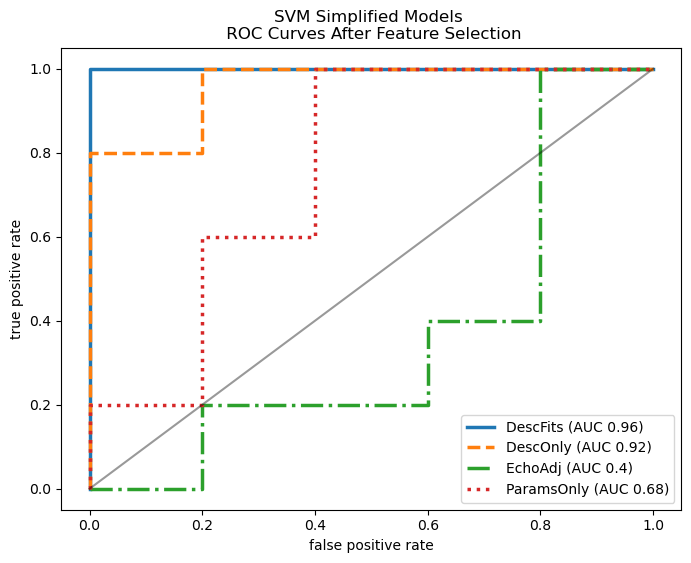

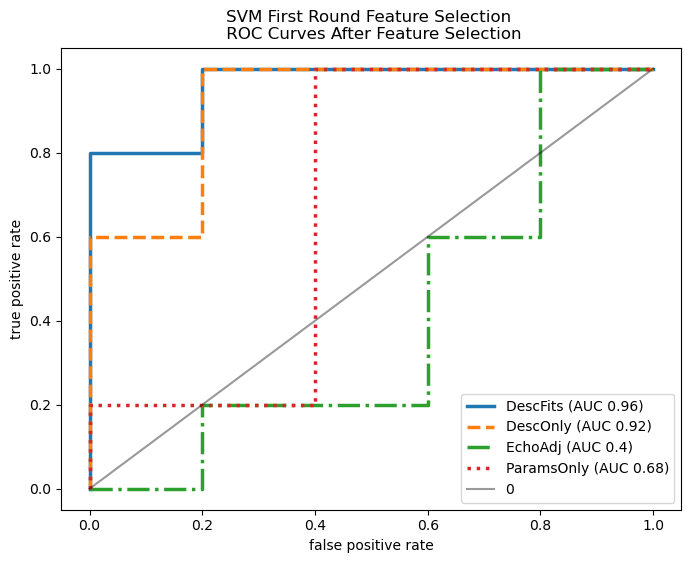

In [45]:
#comparing SVM ROC curves

fig, ax = plt.subplots( figsize = (8,6))

linestyles = ['-', '--', '-.', ':', '']
i = 0
for model in dict_short.keys():
    data = dict_short[model]
    data = data[data['model'] == 'svm best']
    plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth =2.5, 
             label = model  + " (AUC " + auc_second_after[model]['svm best'] + ")")
    i = i+1

plt.plot([0,1], [0,1], 'k-', alpha = 0.4, linewidth = 1.5)
plt.title("SVM Simplified Models \n ROC Curves After Feature Selection")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()
plt.show()

fig, ax = plt.subplots( figsize = (8,6))
i = 0
for model in dict_Long.keys():
    data = dict_Long[model]
    data = data[data['model'] == 'svm best']
    plt.plot(data['fpr'], data['tpr'], linestyles[i], linewidth = 2.5, label = model  + " (AUC " + auc_firstRound_after[model]['svm best'] + ")")
    i = i+1

plt.plot([0,1], [0,1], 'k-', alpha = 0.4, label = '0')
plt.title("SVM First Round Feature Selection \n ROC Curves After Feature Selection")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()
plt.show()
